# SummaryPlot

`SummaryPlot` takes a DataFrame that already contains a model output column and shows how the values are distributed across threshold regions as a stacked bar. It does not evaluate any comfort model — you compute the output first (e.g., with `pmv_ppd_iso` or `utci`) and store it in the DataFrame, then hand the DataFrame to `SummaryPlot`.

This makes it a natural companion to `ThresholdPlot`: the threshold chart shows *where* in the input space conditions fall, and the summary bar shows *how often* they did.

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

from pythermalcomfort.models import pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import SummaryPlot, ThresholdPlot

## 1. Preparing a Measured Dataset

Start by computing the model output and storing it in the DataFrame. `SummaryPlot` only reads the output column — the other columns are ignored.

In [15]:
df = pd.DataFrame(
    {
        "tdb": [20.0, 22.0, 23.5, 24.5, 26.0, 27.5, 29.0, 20.0],
        "rh": [50.0, 45.0, 50.0, 50.0, 55.0, 60.0, 60.0, 65.0],
        "tr": [20.0, 21.5, 23.5, 24.5, 26.0, 28.0, 29.5, 20.0],
        "vr": [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],
        "met": [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        "clo": [0.90, 0.80, 0.60, 0.50, 0.50, 0.40, 0.35, 0.80],
        "wme": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    }
)

df["pmv"] = pmv_ppd_iso(
    tdb=df["tdb"],
    tr=df["tr"],
    vr=df["vr"],
    rh=df["rh"],
    met=df["met"],
    clo=df["clo"],
    wme=df["wme"],
).pmv

df.head(4)

,tdb,rh,tr,vr,met,clo,wme,pmv
0,20.0,50.0,20.0,0.1,1.2,0.9,0.0,-0.50
1,22.0,45.0,21.5,0.1,1.2,0.8,0.0,-0.28
2,23.5,50.0,23.5,0.1,1.2,0.6,0.0,-0.16
3,24.5,50.0,24.5,0.1,1.2,0.5,0.0,-0.06


## 2. Horizontal Bar (Default)

The default layout is a compact horizontal stacked bar. Each segment shows the share of measurements that fell in that region. Percentage labels appear inside segments that are wide enough to fit them; narrow segments are left unlabelled.

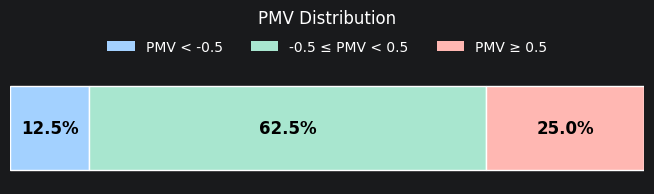

In [16]:
result = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV Distribution")
)
plt.show()

## 3. Vertical Bar

Pass `vertical=True` when the chart needs to fit into a narrow column — for example when placed next to a `ThresholdPlot` (see section 8). The vertical layout keeps the same compact margins while preserving room for the percentage labels.

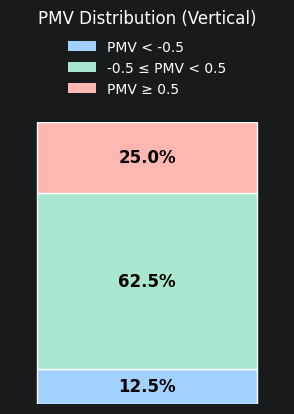

In [17]:
result_v = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(vertical=True, title="PMV Distribution (Vertical)")
)
plt.show()

## 4. Custom Labels, Colors, and Bar Styling

Pass `labels` and `colors` to `set_regions` to override the auto-generated names and the default palette. Both lists must have length `len(thresholds) + 1`. Use `bar_kws` in `plot` for Matplotlib bar styling such as `alpha`, `linewidth`, `hatch`, or `zorder`.

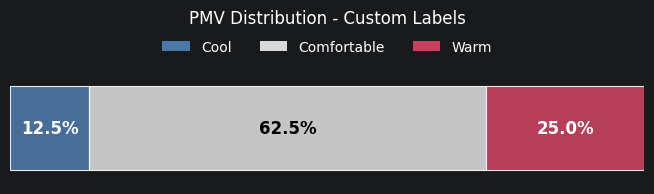

In [18]:
result_custom = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(
        title="PMV Distribution - Custom Labels",
        bar_kws={"alpha": 0.9, "linewidth": 0.8},
    )
)
plt.show()

## 5. Hiding the Legend

Set `legend=False` to remove the colour key. When region labels are provided, they are drawn near the bar segments. Pass `labels=[]` to suppress both the legend and those region labels, which is useful when comparing against a neighbouring plot that already carries the colour key.

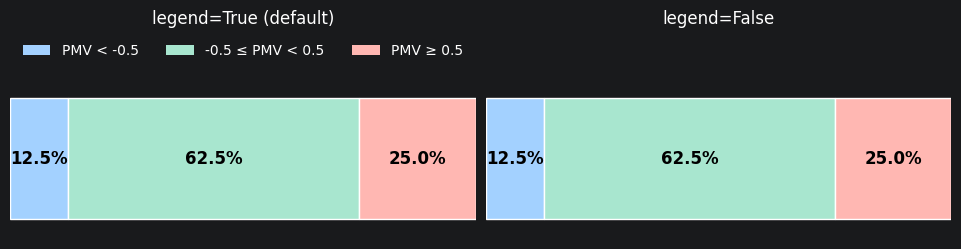

In [19]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.5, 2.4), constrained_layout=True)

left = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="legend=True (default)")
)

right = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5], labels=[])
    .plot(ax=ax1, title="legend=False", legend=False)
)

right.ax.set_ylim(left.ax.get_ylim())
right.ax.set_title(right.ax.get_title(), y=left.ax.title.get_position()[1])

plt.show()

## 6. UTCI with Official Thermal Stress Labels

`SummaryPlot` works with any numeric output column. Here UTCI values are classified into three regions using the official UTCI thermal stress scale. A larger dataset is generated to make the distribution more meaningful.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/utci.py:119: UserWarning: 'v' has value 0.46905381899849224 outside the applicability limits [0.5, 17.0] and will be set to NaN.
  v_valid = valid_range(v, (0.5, 17.0))
/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/utci.py:119: UserWarning: 'v' has value 0.4559036887583093 outside the applicability limits [0.5, 17.0] and will be set to NaN.
  v_valid = valid_range(v, (0.5, 17.0))
/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/utci.py:119: UserWarning: 'v' has value 0.46816562668276857 outside the applicability limits [0.5, 17.0] and will be set to NaN.
  v_valid = valid_range(v, (0.5, 17.0))
/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/utci.py:119: UserWarning: 'v' has value 0.41189960054814195 outside the applicability limits [0.5, 17.0] and will be set to NaN.
  v_valid = valid_range(v, (0.5, 

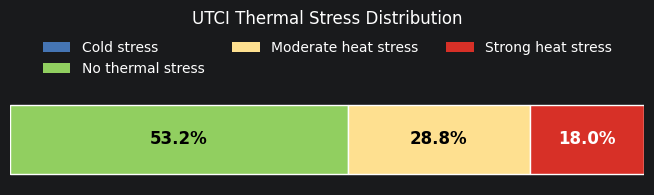

In [20]:
import numpy as np

rng = np.random.default_rng(7)
n = 120
df_utci = pd.DataFrame(
    {
        "tdb": rng.uniform(10, 38, n),
        "tr": rng.uniform(10, 42, n),
        "v": rng.uniform(0.2, 3.5, n),
        "rh": rng.uniform(20, 80, n),
    }
)
df_utci["utci"] = [
    utci(tdb=r.tdb, tr=r.tr, v=r.v, rh=r.rh).utci
    for r in df_utci.itertuples(index=False)
]
# Drop rows where UTCI is NaN — conditions outside the model's applicability
# limits. SummaryPlot requires all values in the output column to be finite.
df_utci = df_utci.dropna(subset=["utci"])

result_utci = (
    SummaryPlot(df_utci)
    .set_regions(
        output="utci",
        thresholds=[9, 26, 32],
        labels=[
            "Cold stress",
            "No thermal stress",
            "Moderate heat stress",
            "Strong heat stress",
        ],
        colors=["#4575b4", "#91cf60", "#fee090", "#d73027"],
    )
    .plot(title="UTCI Thermal Stress Distribution")
)
plt.show()

## 7. Reading `result.percentages`

`result.percentages` is a pandas `Series` indexed by region label. Use it to report compliance figures or pass values to other analyses.

In [21]:
print(result_utci.percentages)
print()

# Pick out a specific region
no_stress = result_utci.percentages["No thermal stress"]
print(f"Time with no thermal stress: {no_stress:.1f} %")

# Check compliance threshold
comfort_share = result_utci.percentages[["No thermal stress"]].sum()
print(f"Overall comfort compliance: {comfort_share:.1f} %")

Cold stress              0.0
No thermal stress       53.2
Moderate heat stress    28.8
Strong heat stress      18.0
Name: proportion, dtype: float64

Time with no thermal stress: 53.2 %
Overall comfort compliance: 53.2 %


## 8. Combined View: Comfort Zones + Time Distribution

Placing a `ThresholdPlot` and a `SummaryPlot` side by side answers two questions at once: *where* in the parameter space do conditions fall, and *what fraction of measurements landed in each region*. Use `labels=[]` and `legend=False` on the `SummaryPlot` when the neighbouring plot already carries the region legend.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:178: UserWarning: 'pmv' has 38 values [2.008721610457417, 2.0181722052286544, 2.027622799999891, 2.0370733947711273, 2.0465239895423637, 2.0559745843135993, 2.005134594140668, 2.0654251790848357, 2.0144772549405854, 2.074875773856072, 2.023819915740502, 2.0843263686273095, 2.033162576540419, 2.093776963398546, 2.042505237340336, 2.1032275581697824, 2.0518478981402537, 2.112678152941019, 2.061190558940171, 2.1221287477122552, 2.0705332197400885, 2.1315793424834912, 2.0798758805400057, 2.1410299372547277, 2.0892185413399234, 2.150480532025965, 2.0067771572061828, 2.0985612021398405, 2.1599311267972015, 2.0159599248609674, 2.107903862939758, 2.169381721568438, 2.0251426925157525, 2.117246523739675, 2.1788323163396743, 2.034325460170537, 2.126589184539592, 2.1882829111109108] at indices [2355, 2393, 2431, 2469, 2507, 2545, 2582, 2583, 2620, 2621, 2658, 2659, 2696, 2697, 2734, 2735, 2772, 2773,

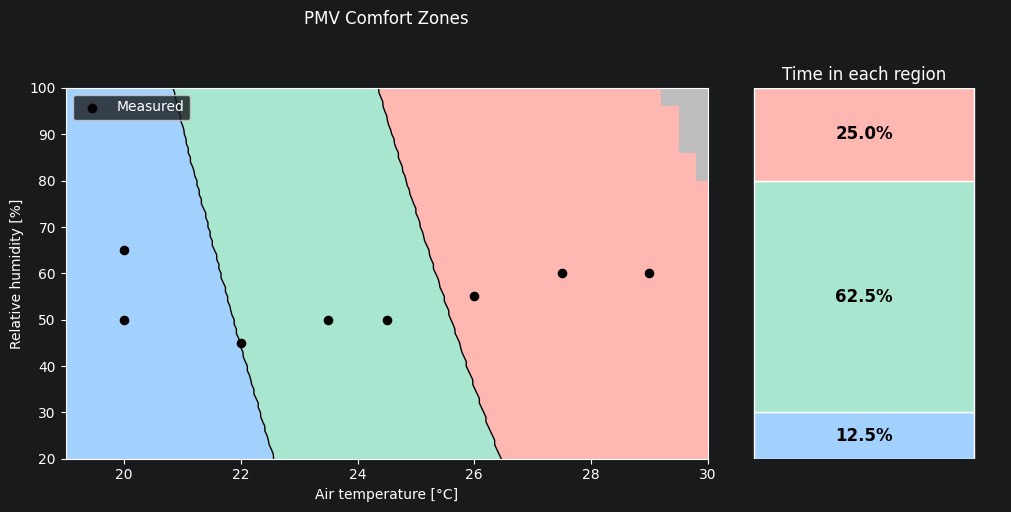

In [22]:
fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [2.8, 1.2]},
)

tp = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 19.0, 30.0, resolution=0.3)
    .set_y_axis("rh", 20.0, 100.0, resolution=1.0)
    .set_params(vr=0.10, met=1.2, clo=0.65, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="PMV Comfort Zones", legend_kws={"ncol": 3})
)
tp.ax.scatter(df["tdb"], df["rh"], color="black", s=35, zorder=5, label="Measured")
tp.ax.legend(loc="upper left")
tp.ax.set_xlabel("Air temperature [°C]")
tp.ax.set_ylabel("Relative humidity [%]")

(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5], labels=[])
    .plot(ax=ax1, vertical=True, title="Time in each region", legend=False)
)

plt.show()

## 9. Using `result.fig`

`result.fig` is the underlying `Figure`. Use it for figure-level operations such as adding a super-title or saving to disk.

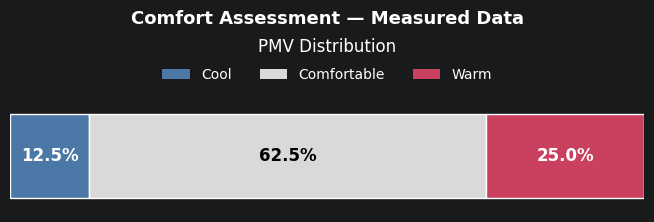

In [23]:
r = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="PMV Distribution")
)

r.fig.suptitle(
    "Comfort Assessment — Measured Data", y=1.14, fontsize=13, fontweight="bold"
)

# r.fig.savefig("pmv_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Custom Bar Properties with `bar_kws`

`bar_kws` forwards Matplotlib bar keyword arguments to the stacked bar segments. This is useful for changing visual properties such as transparency, edge styling, line width, or hatch patterns.

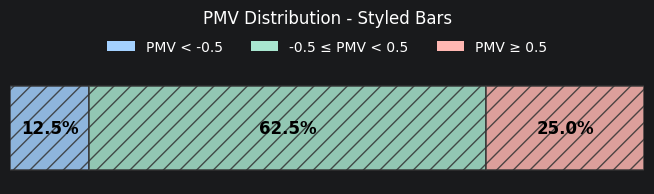

In [24]:
(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        title="PMV Distribution - Styled Bars",
        bar_kws={
            "alpha": 0.85,
            "edgecolor": "#333333",
            "linewidth": 1.2,
            "hatch": "//",
        },
    )
)

plt.show()

Matplotlib uses different size arguments for horizontal and vertical bars. For a horizontal `barh` chart, `height` controls the bar thickness. For a vertical `bar` chart, `width` controls the bar thickness.

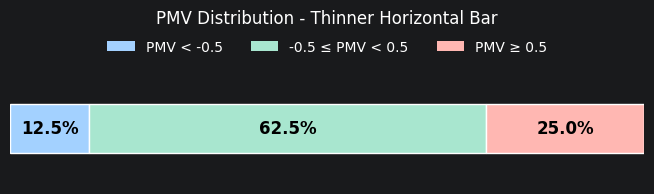

In [25]:
(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        title="PMV Distribution - Thinner Horizontal Bar",
        bar_kws={"height": 0.42},
    )
)

plt.show()

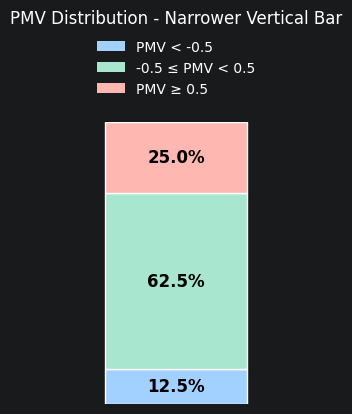

In [26]:
(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        vertical=True,
        title="PMV Distribution - Narrower Vertical Bar",
        bar_kws={"width": 0.52},
    )
)

plt.show()